In [1]:
import os
import sys
import time
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import pickle as pkl
import matplotlib.dates as mdates
from shapely.geometry import Point
from sklearn.metrics import r2_score, mean_absolute_error
from geopy.distance import geodesic

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

### change directory to import more scripts
sys.path.append(str(Path().resolve().parents[0]))

from utils import tools
import generate_wind

if os.getcwd().split(os.sep)[-1] == 'evaluation':
    os.chdir('..')

In [2]:
config = tools.load_config("configs/config.yaml")

synth_name = 'renewablesninja'
reninja_name = 'renewablesninja'

val_dir = 'data/Trianel_Benchmark'
synth_dir = os.path.join(config['data']['synth_dir'], 'wind', synth_name)
reninja_dir = os.path.join(config['data']['synth_dir'], 'wind', reninja_name)
locations_dir = os.path.join(config['data']['synth_dir'], 'wind', 'noage')
turbine_dir = config['data']['turbine_dir']
turbine_power = config['data']['turbine_power']
turbine_path = os.path.join(turbine_dir, turbine_power)
specs_path = config['data']['turbine_specs']
specs_path = os.path.join(turbine_dir, specs_path)
cp_path = config["data"]["turbine_cp"]
cp_path = os.path.join(turbine_dir, cp_path)
results_dir = f'results/{synth_name}'
geojsn_dir = 'misc/geoBoundaries-DE.geojson'
os.makedirs(results_dir, exist_ok=True)
save_path = 'figs'

features = config['features']

params = config['wind_params']

In [3]:
files = os.listdir(synth_dir)
station_files_synthetic = [f for f in files if 'parameter' not in f and f.endswith('.csv')]
station_files_synthetic.sort()
print(len(station_files_synthetic), 'station files in synthetic data found')
turbine_params = pd.read_csv(os.path.join(synth_dir, 'turbine_parameter.csv'), sep=';')
wind_params = pd.read_csv(os.path.join(synth_dir, 'wind_parameter.csv'), sep=';', dtype={"park_id": str})
all_wind_params = pd.read_csv(os.path.join(locations_dir, 'wind_parameter.csv'), sep=';', dtype={"park_id": str})

7 station files in synthetic data found


In [4]:
timestamp_col = 'timestamp'
dfs = []
for st in station_files_synthetic:
    station = pd.read_csv(os.path.join(synth_dir, st), sep=';')
    station[timestamp_col] = pd.to_datetime(station[timestamp_col], utc=True)
    station.set_index(timestamp_col, inplace=True)
    #station = station['2024-01-01':'2024-12-31']
    #metadata = pd.read_csv(os.path.join(path, md))
    dfs.append(station)
    power_cols = [col for col in station.columns if 'power' in col]
    power = 0
    for col in power_cols:
        power += station[col]
    power /= 1000 # convert to kW
    station['synthetic'] = power

In [5]:
masterdata = pd.read_csv(os.path.join(val_dir, 'masterdata_wind_20240601.csv'), sep=';')
meterdata = pd.read_csv(os.path.join(val_dir, 'meterdata_wind_20240601.csv'), sep=';')
meterdata['Zeit'] = pd.to_datetime(meterdata['Zeit'], utc=True)
meterdata.set_index('Zeit', inplace=True)

In [6]:
m = folium.Map(location=[51.0, 10.0], zoom_start=6)

# --- 4. Punkte aus df1: rote Marker mit Tooltip ---
for _, row in all_wind_params.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        tooltip=f"Park ID: {row['park_id']}<br>Lat: {row['latitude']:.4f}, Lon: {row['latitude']:.4f}"
    ).add_to(m)

# --- 5. Punkte aus df2: blaue Marker mit Tooltip ---
for _, row in masterdata.iterrows():
    folium.CircleMarker(
        location=[row['Koordinaten Breite (WGS 84)'], row['Koordinaten Länge (WGS 84)']],
        radius=5,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.8,
        tooltip=f"Lat: {row['Koordinaten Breite (WGS 84)']:.4f}, \
                  Lon: {row['Koordinaten Länge (WGS 84)']:.4f}, \
                  Malo-ID: {row['Malo-ID']}, \
                  Park Name: {row['Parkname']}"
    ).add_to(m)
m.save('map.html')

In [7]:
#stations = ['SL Windpark Kengen GmbH & Co. KG', 'WKA Höheinöd', 'Windpark Jettebruch', 'Windpark Trendelburg']
#masterdata[masterdata['Parkname'].isin(stations)].groupby('Parkname').agg({'Koordinaten Breite (WGS 84)': 'mean', 'Koordinaten Länge (WGS 84)': 'mean'})
masterdata.groupby('Parkname').agg({'Koordinaten Breite (WGS 84)': 'mean', 'Koordinaten Länge (WGS 84)': 'mean'})

,Koordinaten Breite (WGS 84),Koordinaten Länge (WGS 84)
Parkname,,
Barlt West,54.013534,9.015634
Eggstedt IV,54.063132,9.234286
Jessin/Grimmen,54.091557,12.993016
Lintern Wind GmbH & Co. KG,51.923447,7.209676
SL Windpark Baumberge GmbH & Co. KG,51.930808,7.224198
SL Windpark Issum GmbH & Co. KG,51.477871,6.447653
SL Windpark Kengen GmbH & Co. KG,51.471579,6.439445
SL Windpark Rheurdt GmbH & Co. KG,51.461174,6.433555
"TWV, Windpark Vogelherd",49.955388,11.416878


In [8]:
meterdata = meterdata['2023-07-24':]
meterdata.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30049 entries, 2023-07-24 00:00:00+00:00 to 2024-06-01 00:00:00+00:00
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   50082792290  30049 non-null  float64
 1   50361225962  0 non-null      float64
 2   50414611745  30049 non-null  float64
 3   50421485125  30045 non-null  float64
 4   50421572237  30025 non-null  float64
 5   50446515501  30049 non-null  float64
 6   50454932698  30049 non-null  float64
 7   50483800543  30049 non-null  float64
 8   50646350971  30045 non-null  float64
 9   50646350997  30045 non-null  float64
 10  50646396058  30045 non-null  float64
 11  50852909827  30049 non-null  float64
 12  51164756609  14597 non-null  float64
 13  51279106971  30049 non-null  float64
 14  51443998641  30049 non-null  float64
dtypes: float64(15)
memory usage: 3.7 MB


In [9]:
# def interpolate_points(coord1, coord2, step_m=100):
#     """Erzeugt Punkte alle step_m Meter entlang der Linie zwischen coord1 und coord2."""
#     total_dist = geodesic(coord1, coord2).m  # Distanz in Metern
#     n_points = max(int(total_dist // step_m), 2)
#     lats = np.linspace(coord1[0], coord2[0], n_points)
#     lons = np.linspace(coord1[1], coord2[1], n_points)
#     return list(zip(lats, lons))

# def get_elevation_batch(coords_list):
#     lats = ",".join([str(c[0]) for c in coords_list])
#     lons = ",".join([str(c[1]) for c in coords_list])
#     url = f"https://api.open-meteo.com/v1/elevation?latitude={lats}&longitude={lons}"
#     response = requests.get(url)
#     return response.json()['elevation']

# def get_elevation(coords):
#     lat, lon = coords
#     url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
#     return requests.get(url).json()['results'][0]['elevation']


# columns = ['Malo-ID', 'Koordinaten Breite (WGS 84)', 'Koordinaten Länge (WGS 84)']
# centroids = masterdata.groupby('Parkname')[columns].mean().reset_index()
# centroids['Malo-ID'] = centroids['Malo-ID'].astype(str)
# results = []
# for _, park in centroids.iterrows():
#     park_coords = (park['Koordinaten Breite (WGS 84)'], park['Koordinaten Länge (WGS 84)'])
#     distances = all_wind_params.apply(
#         lambda row: geodesic(park_coords, (row['latitude'], row['longitude'])).km, axis=1)
#     nearest_station = all_wind_params.loc[distances.idxmin()]
#     station_coords = (nearest_station['latitude'], nearest_station['longitude'])

#     # Höhenprofil zwischen Park und Station
#     points = interpolate_points(park_coords, station_coords, step_m=200)

#     # Batch-Abfrage (API kann ggf. max. ~100 Punkte pro Call)
#     elevations = []
#     batch_size = 5
#     for i in range(0, len(points), batch_size):
#         batch = points[i:i+batch_size]
#         elevations.extend(get_elevation_batch(batch))
#         time.sleep(1)

#     std_elevation = np.std(elevations)
#     park_elevation = get_elevation(park_coords)

#     results.append({
#         'park_name': park['Parkname'],
#         'malo-id': str(park['Malo-ID']).split('.')[0],
#         'park_id': nearest_station['park_id'],
#         'distance_km': distances[distances.idxmin()],
#         'altitude': nearest_station['altitude'],
#         'park_elevation': park_elevation,
#         'std_elevation': std_elevation
#     })

# next_station = pd.DataFrame(results)


In [10]:
#next_station

In [11]:
def get_elevation(coords):
    lat, lon = coords
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    return requests.get(url).json()['results'][0]['elevation']

# get nearest stations to parks

columns = ['Malo-ID', 'Koordinaten Breite (WGS 84)', 'Koordinaten Länge (WGS 84)']
centroids = masterdata.groupby('Parkname')[columns].mean().reset_index()
centroids['Malo-ID'] = centroids['Malo-ID'].astype(str)
results = []
for _, park in centroids.iterrows():
    park_coords = (park['Koordinaten Breite (WGS 84)'], park['Koordinaten Länge (WGS 84)'])
    distances = all_wind_params.apply(
        lambda row: geodesic(park_coords, (row['latitude'], row['longitude'])).km, axis=1)
    nearest_station = all_wind_params.loc[distances.idxmin()]
    # get park elevation
    #park_elevation = get_elevation(park_coords)
    results.append({
        'park_name': park['Parkname'],
        'malo-id': str(park['Malo-ID']).split('.')[0],
        'park_id': nearest_station['park_id'],
        'distance_km': distances[distances.idxmin()],
        'altitude': nearest_station['altitude'],
        #'park_elevation': park_elevation
        #'commissioning_date': nearest_station['commissioning_date']
    })
    time.sleep(0.5)
next_station = pd.DataFrame(results)
# paar stationen droppen
next_station.drop(next_station[next_station.park_name == 'SL Windpark Issum GmbH & Co. KG'].index, inplace=True)

next_station.sort_values('distance_km')

,park_name,malo-id,park_id,distance_km,altitude
13,Windpark Jettebruch,50421572237,04745,3.150501,75.0
0,Barlt West,50454932698,01200,6.193933,3.0
1,Eggstedt IV,50446515501,01200,14.666721,3.0
15,Windpark Trendelburg,50421485125,05347,18.351631,236.0
3,Lintern Wind GmbH & Co. KG,51443998641,07374,25.479156,46.0
4,SL Windpark Baumberge GmbH & Co. KG,51443998641,07374,25.667804,46.0
9,Trianel Windpark Eisleben (TWE),50082792290,00198,28.811703,164.0
10,Vogelsberg,51164756609,00198,30.472748,164.0
2,Jessin/Grimmen,50483800543,00298,33.268116,3.0
12,WP Moosmoor,50361225962,00704,33.511035,11.0


In [ ]:
# mapping = {'Windpark Jettebruch': 'jettebruch',
#          'Barlt West': 'barlt_west',
#          'Windpark Trendelburg': 'trendelburg',
#          'WKA Höheinöd': 'hoeheinoed',
#          'SL Windpark Kengen GmbH & Co. KG': 'kengen',
#          'Eggstedt IV': 'eggstedt',
#          'Lintern Wind GmbH & Co. KG': 'lintern',
#          'Trianel Windpark Eisleben (TWE)': 'eisleben',
#          'Vogelsberg': 'vogelsberg',
#          'Jessin/Grimmen': 'jessin_grimmen',
#          'TWV, Windpark Vogelherd': 'twv_windpark',
#          'SL Windpark Rheurdt GmbH & Co. KG': 'rheurdt',
#          'Windpark Mattenberg': 'mattenberg',
#          }

# csv_path = os.path.join(val_dir, 'trianel_hourly')

# os.makedirs(csv_path, exist_ok=True)

# for _, row in next_station.iterrows():
#     malo_id = row['malo-id']
#     if not row['park_name'] in mapping:
#         continue
#     park_name = mapping[row['park_name']]
#     station_data = meterdata[[malo_id]].copy()
#     station_data.rename(columns={malo_id: 'power'}, inplace=True)
#     station_data.to_csv(os.path.join(csv_path, f'{park_name}.csv'), sep=';')

In [27]:

windpark_of_interest = 'WKA Höheinöd'
cols = ['Parkname', 'Malo-ID', 'Installierte Leistung (kW)', 'Hersteller', 'Typ', 'Nabenhöhe (m)', 'Rotordurchmesser (m)']
next_station.drop(next_station[next_station.park_name == 'SL Windpark Issum GmbH & Co. KG'].index, inplace=True)
masterdata[masterdata.Parkname == windpark_of_interest][cols]

,Parkname,Malo-ID,Installierte Leistung (kW),Hersteller,Typ,Nabenhöhe (m),Rotordurchmesser (m)
14,WKA Höheinöd,50414611745,3300.0,Vestas,V126 3300,137.0,126.0


In [164]:
def plot_power_curve(data: pd.DataFrame, power_curve: pd.Series, station_id: str = None,
                     save_path: str = None, outliers: pd.DataFrame = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    x = data['wind_speed_hub'].values
    y = data['real'].values
    z = data['synthetic'].values
    #cp_x = data['wind_speed_hub']
    #cp_y = data['Cp']

    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]
    z = z[mask]

    fig, ax1 = plt.subplots(figsize=(7, 5))

    # Outlier zuerst plotten (damit sie hinter den anderen Punkten liegen)
    if outliers is not None and len(outliers) > 0:
        ox = outliers['wind_speed_hub'].values
        oy = outliers['real'].values
        if station_id == '02483':
            ox = ox + 1.5
        ax1.scatter(ox, oy, s=10, alpha=0.5, color='red', label='Outlier', zorder=1)

    if station_id == '02483':
        x_new = x + 1.5
    else:
        x_new = x

    ax1.scatter(x_new, y, s=10, alpha=0.5, color='blue', label='Real power', zorder=2)
    ax1.scatter(x, z, s=10, alpha=0.5, color='darkorange', label='Renewables.ninja power', zorder=2)
    ax1.plot(power_curve, color='black', linewidth=2, label='Ideal power curve')
    ax1.set_xlabel("Extrapolated Wind Speed at Hub [m/s]", fontsize=12)
    ax1.set_ylabel("Power [kW]", fontsize=12)
    ax1.legend(loc="center right", fontsize=12)
    ax1.tick_params(axis='both', labelsize=12)

    # ax2 = ax1.twinx()
    # ax2.scatter(cp_x, cp_y, s=10, alpha=0.5, color='green', label='Cp')
    # ax2.set_ylabel("Power Coefficient ($C_p$)", color='green')
    # ax2.tick_params(axis='y', labelcolor='green')

    plt.tight_layout()

    if save_path:
        plt.savefig(f'{save_path}/power_curve_{station_id}', bbox_inches='tight')
        plt.close()
    else:
        plt.show()

def plot_daily_load_profile(data: pd.DataFrame, date_of_interest: str = None, save_path: str = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    for date, day_df in data.groupby(data.index.date):
        if date_of_interest and str(date) != date_of_interest:
            continue
        fig, ax1 = plt.subplots(figsize=(8, 4))

        ax1.plot(day_df.index, day_df['synthetic'], color='red', label='Synthetic')
        ax1.plot(day_df.index, day_df['real'], color='blue', label='Real')

        ax1.set_xlabel('Time [UTC]')
        ax1.set_ylabel('Power [kW]')
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        ax2.plot(day_df.index, day_df['wind_speed_hub'], color='green', linestyle='--', label='Wind Speed')
        ax2.set_ylabel('Wind Speed [m/s]')
        ax2.legend(loc='lower right')

        # x-Achse formatieren: alle 3 Stunden, nur Uhrzeit
        ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        plt.title(f'Load and Wind Speed on {date}')
        plt.tight_layout()

        if save_path:
            filename = f"{save_path}/daily_{date}.png"
            plt.savefig(filename, dpi=300)
            plt.close()
        else:
            plt.show()

def plot_sum_produced(data: pd.Series, station_id: str = None, save_path: str = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    change_pct = 1 - data['synthetic'] / data['real']
    if change_pct < 0:
        color = 'green'
        change_text = f"{change_pct * 100:.1f}%"
    else:
        color = 'red'
        change_text = f"-{change_pct * 100:.1f}%"

    colors = ['darkorange', 'blue']
    fig, ax1 = plt.subplots(figsize=(3, 4))
    sns.barplot(x=data.index, y=data.values, ax=ax1)
    plt.ylabel('Produced Energy [MWh]')
    plt.xlabel('')

    synthetic_height = data['synthetic']
    ax1.text(
        x=0,  # Index "synthetic"
        y=synthetic_height + 5,  # etwas über dem Balken
        s=change_text,
        color=color,
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
    plt.tight_layout()

    if save_path:
        filename = f"{save_path}/sum_produced_energy_{station_id}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()

def plot_error_distribution(data: pd.Series, station_id: str = None, save_path: str = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    sns.histplot(data, bins=50, stat='density')
    plt.xlabel('Real - Synthetic [kW]')
    plt.ylabel('Density')
    if save_path:
        filename = f"{save_path}/error_distribution_{station_id}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()

def plot_wind_bin_errors(data: pd.DataFrame, station_id: str = None, save_path = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    bin_size = 1
    df = data.copy()
    df.dropna(inplace=True)
    df['wind_speed_bin'] = df['wind_speed_hub'].apply(lambda x: round(x / bin_size) * bin_size)
    plt.figure(figsize=(16, 6))
    sns.boxplot(
        data=df,
        x="wind_speed_bin",
        y="bias",
        showfliers=False,
        #palette=""
    )
    plt.xlabel("Wind Speed Bin [m/s]")
    plt.ylabel("Real - Synthetic [kW]")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    if save_path:
        filename = f"{save_path}/wind_bin_error_{station_id}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()

def plot_power_bin_errors(data: pd.DataFrame, station_id: str = None, save_path = None):
    if save_path: os.makedirs(save_path, exist_ok=True)
    bin_size = 500
    df = data.copy()
    df.dropna(inplace=True)
    df['power_bin'] = df['real'].apply(lambda x: round(x / bin_size) * bin_size)
    plt.figure(figsize=(16, 6))
    sns.boxplot(
        data=df,
        x="power_bin",
        y="bias",
        showfliers=False,
        #palette=""
    )
    plt.xlabel("Power Bin [kW]")
    plt.ylabel("Real - Synthetic [kW]")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    if save_path:
        filename = f"{save_path}/power_bin_error_{station_id}.png"
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()

def get_power_curves(turbine_path: str, turbine_params: pd.DataFrame):
    power_curves = pd.read_csv(turbine_path, sep=";", decimal=",")
    power_curves.set_index('wind_speed', inplace=True)
    turbines = turbine_params['turbine_name'].tolist()
    power_curves = power_curves[turbines]
    if power_curves.columns.duplicated().any():
        power_curves = power_curves.loc[:, ~power_curves.columns.duplicated()]
    final_power_curves = pd.DataFrame()
    for turbine in turbines:
        cut_out = turbine_params.loc[turbine_params.turbine_name == turbine]['cut_out'].iloc[0]
        power_curve = generate_wind.interpolate(power_curve=power_curves[turbine],
                                                cut_out=cut_out)
        final_power_curves[turbine] = power_curve
    return final_power_curves

In [165]:
# load best db scan params

with open('results/best_dbscan_params.pkl', 'rb') as f:
    best_dbscan_params = pkl.load(f)

In [189]:
id_of_interest = None# '04745'
results = defaultdict(list)
densities = []
trues, preds = [], []

for file, df in zip(station_files_synthetic, dfs):
    print(f'Processing: {file}')
    if len(file) == 15:
        station_id = file.split('.')[0][-5:]
    else:
        station_id = file.split('.')[0][-7:]
    # initialize paths
    daily_load_profile_path = os.path.join(results_dir, 'daily_profiles', station_id)
    sum_produced_path = os.path.join(results_dir, 'sum_produced')
    power_curve_path = os.path.join(results_dir, 'power_curve')
    error_distribution_path = os.path.join(results_dir, 'error_distribution')
    wind_bin_error_path = os.path.join(results_dir, 'wind_bin_error')
    power_bin_error_path = os.path.join(results_dir, 'power_bin_error')
    # get list of turbine ids t1,...
    turbines = turbine_params.loc[turbine_params.park_id == station_id]
    cut_in = turbines.cut_in.max()
    # get malo-id from station
    malo_ids = next_station.loc[next_station.park_id == station_id[:5]]['malo-id']
    malo_id = malo_ids.iloc[0]
    if malo_id in results['malo-id'] and station_id not in results['station_id']:
        malo_id = malo_ids.iloc[1]
    elif malo_id in results['malo-id'] and station_id in results['station_id']:
        continue
    results['malo-id'].append(str(malo_id))
    results['station_id'].append(station_id)
    df_compare = pd.concat([df[:meterdata[malo_id].index[-1]], meterdata[malo_id]], axis=1)
    # get mean wind_speed and density accross all heights
    mean_wind_speed, mean_density = 0, 0
    # get park power curve
    power_curves = get_power_curves(turbine_path=turbine_path, turbine_params=turbines)
    power_curve = np.zeros(len(power_curves))
    if synth_name == 'renewablesninja':
        df_compare['synthetic'] *= 1000
        weighting = {'00198_1': {'t1': 1/11, 't2': 6/11, 't3': 4/11},
                     '00198_2': {'t1': 2/10, 't2': 2/10, 't3': 6/10}}
        if station_id in weighting:
            for turbine, weight in weighting[station_id].items():
                mean_wind_speed += df_compare[f'wind_speed_{turbine}'] * weight
        else:
            wind_speed_cols = [col for col in df_compare.columns if 'wind_speed' in col]
            for wind_speed_col in wind_speed_cols:
                mean_wind_speed += df_compare[wind_speed_col]
            mean_wind_speed /= len(wind_speed_cols)
        for _, row in turbines.iterrows():
            power_curve += power_curves[row['turbine_name']]
    else:
        for _, row in turbines.iterrows():
            mean_wind_speed += df_compare[f'wind_speed_{row['turbine']}']
            mean_density += df_compare[f'density_{row['turbine']}']
            power_curve += power_curves[row['turbine_name']]
        mean_wind_speed /= len(turbines['turbine'])
        mean_density /= len(turbines['turbine'])
        df_compare['density_hub'] = mean_density
        densities.extend(mean_density)
    df_compare['wind_speed_hub'] = mean_wind_speed
    df_compare.rename(columns={malo_id: 'real'}, inplace=True)
    df_compare = df_compare.resample('1h', closed='left', label='left', origin='start').mean()
    # get Cp for entire park
    # A = 0
    # for i, row in turbines.iterrows():
    #     A += np.pi * (row['diameter']/2) ** 2
    # df_compare['Cp'] = (df_compare.synthetic * 1000) / (0.5 * A * df_compare.density_hub * df_compare.wind_speed_hub ** 3)
    # copy raw frame to filter outliers from real data
    # eps_list = np.arange(0.01, 0.3, 0.01)
    # min_samples_list = np.arange(1, 100, 1)
    # best_r2 = 0
    # if file == 'synth_00198_2.csv':
    #     for eps in eps_list:
    #         for min_sample in min_samples_list:
    #             df_lean = df_compare.copy()
    #             X_db = df_lean[['wind_speed_hub', 'real']].dropna()
    #             X_scaled = StandardScaler().fit_transform(X_db)
    #             best_params = best_dbscan_params[station_id]
    #             #labels = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples']).fit_predict(X_scaled)
    #             labels = DBSCAN(eps=eps, min_samples=min_sample).fit_predict(X_scaled)
    #             dbscan_outliers = df_lean.loc[X_db.index[labels == -1]]
    #             df_lean = df_lean.loc[X_db.index[labels != -1]]
    #             # Alle Outlier zusammenfassen
    #             outliers = pd.concat([cut_in_outliers, dbscan_outliers])
    #             bias = df_lean['real'] - df_lean['synthetic']
    #             df_lean['bias'] = bias
    #             sum_produced = df_lean[['synthetic', 'real']].sum(axis=0) / 1000 # divide by 2 when resolution is 30 min
    #             # get metrics
    #             y_true = df_lean.dropna()['real']
    #             y_pred = df_lean.dropna()['synthetic']
    #             if len(y_true) == 0:
    #                 continue
    #             r_2 = r2_score(y_true=y_true, y_pred=y_pred)
    #             print(f'eps: {eps}, min_samples: {min_sample}, r2: {r_2}, len(outliers): {len(outliers)}')
    #             if (r_2 > best_r2) and (len(outliers) / len(df_lean) < 0.2):
    #                 best_eps = eps
    #                 best_min_sample = min_sample
    #                 best_r2 = r_2
    # best_dbscan_params['00198_2']['eps'] = best_eps
    # best_dbscan_params['00198_2']['min_samples'] = best_min_sample
    df_lean = df_compare.copy()
    # if station_id == '02483':
    #     df_lean['wind_speed_hub'] += 1
    # remove 0 production where wind speed is > cut_in
    wind_speed_cols = [col for col in df_lean.columns if 'wind_speed_t' in col]
    df_lean['min_wind_speed'] = df_lean[wind_speed_cols].min(axis=1)
    # Outlier aus Cut-In Filter merken
    cut_in_outliers = df_lean[(df_lean['real'] == 0) & (df_lean['min_wind_speed'] >= cut_in)]
    df_lean = df_lean[~((df_lean['real'] == 0) & (df_lean['min_wind_speed'] >= cut_in))]
    # DBSCAN Outlier merken
    X_db = df_lean[['wind_speed_hub', 'real']].dropna()
    # hpo for best dbscan parameters:
    X_scaled = StandardScaler().fit_transform(X_db)
    best_params = best_dbscan_params[station_id]
    labels = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples']).fit_predict(X_scaled)
    dbscan_outliers = df_lean.loc[X_db.index[labels == -1]]
    df_lean = df_lean.loc[X_db.index[labels != -1]]
    # Alle Outlier zusammenfassen
    outliers = pd.concat([cut_in_outliers, dbscan_outliers])
    bias = df_lean['real'] - df_lean['synthetic']
    df_lean['bias'] = bias
    sum_produced = df_lean[['synthetic', 'real']].sum(axis=0) / 1000 # divide by 2 when resolution is 30 min
    # get metrics
    y_true = df_lean.dropna()['real']
    y_pred = df_lean.dropna()['synthetic']
    r_2 = r2_score(y_true=y_true, y_pred=y_pred)
    installed_capacity = power_curve.max()
    y_true /= installed_capacity
    y_pred /= installed_capacity
    trues.extend(y_true)
    preds.extend(y_pred)
    mae = mean_absolute_error(y_true=y_true, y_pred=y_pred)
    results['r^2'].append(r_2)
    results['mae'].append(mae)
    results['sum_MWh_real'].append(sum_produced['real'])
    results['sum_MWh_synthetic'].append(sum_produced['synthetic'])
    results['installed_capacity'].append(installed_capacity)
    if station_id == id_of_interest:
        break
    #plot_daily_load_profile(data=df_lean, save_path=daily_load_profile_path)
    #plot_power_curve(data=df_lean, power_curve=power_curve, station_id=station_id, save_path=power_curve_path, outliers=outliers)
    #plot_sum_produced(data=sum_produced, station_id=station_id, save_path=sum_produced_path)
    #plot_error_distribution(data=bias, station_id=station_id, save_path=error_distribution_path)
    #plot_wind_bin_errors(data=df_lean, station_id=station_id, save_path=wind_bin_error_path)
    #plot_power_bin_errors(data=df_lean, station_id=station_id, save_path=power_bin_error_path)

results = next_station.merge(pd.DataFrame(results), on='malo-id', how='left')
results.to_csv(os.path.join(results_dir, 'evaluation.csv'), index=False)

Processing: 00198_1.csv
Processing: 00198_2.csv
Processing: 00282.csv
Processing: 02483.csv
Processing: 04745.csv
Processing: 05347.csv
Processing: 05426.csv


In [141]:
subset = df_lean[['wind_speed_10m', 'synthetic', 'real', 'wind_speed_hub', 'bias']]

In [142]:
subset['bias'] *= -1

/var/folders/pz/kvbp4_tx4gj8hj2xjrqppmvr0000gn/T/ipykernel_4349/4193891446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['bias'] *= -1


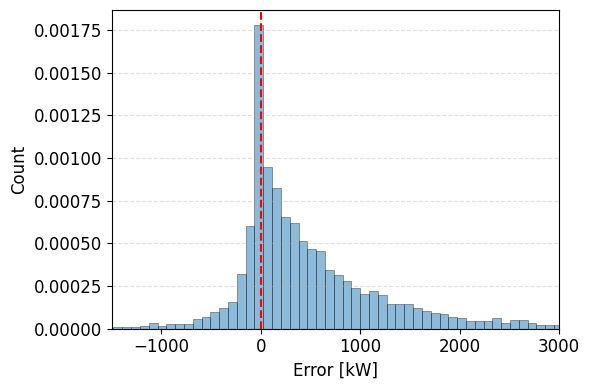

In [128]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(subset.bias, bins=100, density=True,
        alpha=0.5, color='C0', edgecolor='black', linewidth=0.5, label='era5+aging')
# ax.hist(reninja.bias, bins=100, density=True,
#         alpha=0.5, color='C1', edgecolor='black', linewidth=0.5, label='Renewables.ninja')
ax.set_xlabel('Error [kW]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_xlim(-1500, 3000)
#ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join('figs', 'error_lower_saxpny.png'), dpi=600)
plt.show()

In [ ]:
wind = subset.merge(subset_frac, how='left', left_index=True, right_index=True)

error_10m = wind['wind_speed_10m'] - wind['wind_speed']
error_hub = wind['wind_speed_hub_x'] - wind['wind_speed_hub_y']

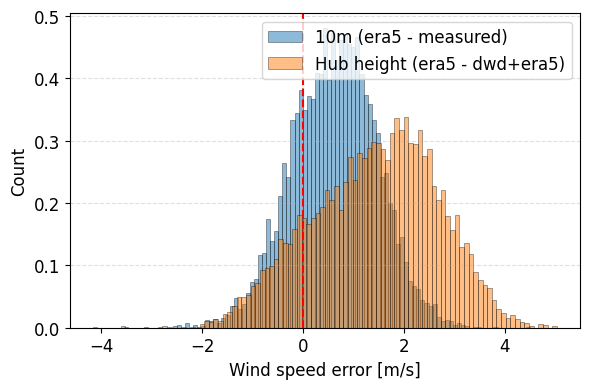

In [153]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(error_10m, bins=100, density=True,
        alpha=0.5, color='C0', edgecolor='black', linewidth=0.5, label='10m (era5 - measured)')
ax.hist(error_hub, bins=100, density=True,
        alpha=0.5, color='C1', edgecolor='black', linewidth=0.5, label='Hub height (era5 - dwd+era5)')
ax.set_xlabel('Wind speed error [m/s]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(x=0, color='red', linestyle='--')
#ax.set_xlim(-1500, 3000)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join('figs', 'wind_error_lower_saxpny.png'), dpi=600)
plt.show()

In [24]:
results

,park_name,malo-id,park_id,distance_km,altitude,park_elevation,station_id,r^2,mae,sum_MWh_real,sum_MWh_synthetic,installed_capacity
0,Barlt West,50454932698,01200,6.193933,3.0,0.0,01200_1,0.742015,0.096522,29795.807909,38013.220537,16800.00
1,Eggstedt IV,50446515501,01200,14.666721,3.0,18.0,01200_2,0.628029,0.109806,26068.217671,36408.556648,16000.00
2,Jessin/Grimmen,50483800543,00298,33.268116,3.0,15.0,00298,0.893963,0.075569,4420.400818,4421.402949,2000.00
3,Lintern Wind GmbH & Co. KG,51443998641,07374,25.479156,46.0,122.0,NaN,NaN,NaN,NaN,NaN,NaN
4,SL Windpark Baumberge GmbH & Co. KG,51443998641,07374,25.667804,46.0,119.0,NaN,NaN,NaN,NaN,NaN,NaN
5,SL Windpark Kengen GmbH & Co. KG,50646396058,01303,37.491446,150.0,35.0,01303_1,0.763572,0.070216,3462.929500,4242.993146,2430.00
6,SL Windpark Rheurdt GmbH & Co. KG,50646350997,01303,37.684676,150.0,32.0,01303_2,0.739966,0.058316,10323.933250,12290.538877,9000.00
7,"TWV, Windpark Vogelherd",51279106971,00282,36.767137,240.0,544.0,00282,0.817798,0.095815,43662.081498,39394.034100,19200.00
8,Trianel Windpark Eisleben (TWE),50082792290,00198,28.811703,164.0,232.0,00198_1,0.704646,0.094420,50423.638692,51843.761873,26810.00
9,Vogelsberg,51164756609,00198,30.472748,164.0,239.0,00198_2,0.807518,0.105320,39246.768000,42383.177789,35100.00


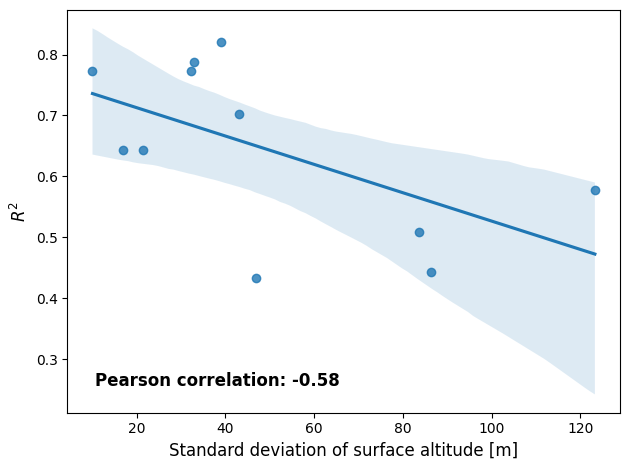

In [78]:
mask_saxony = results['park_name'] == 'Windpark Jettebruch'
results.loc[mask_saxony, ['r^2']] = 0.698383 # dwd+era5

r2_values = {
    'Windpark Mattenberg': 0.578383,
    'SL Windpark Kengen GmbH & Co. KG': 0.787886,
    'SL Windpark Rheurdt GmbH & Co. KG': 0.772523
}
for name, val in r2_values.items():
    results.loc[results['park_name'] == name, 'r^2'] = val

idea = results.loc[results.distance_km >= 15]

sns.regplot(x=idea['std_elevation'], y=idea['r^2'])
plt.ylabel('$R^2$', fontsize=12)
plt.xlabel('Standard deviation of surface altitude [m]', fontsize=12)
#plt.title(f'{metrics} aging', fontsize=12)
corr = idea['std_elevation'].corr(idea['r^2'])
plt.text(0.05, 0.1, f'Pearson correlation: {corr:.2f}', transform=plt.gca().transAxes, fontweight='bold', va='top', fontsize=12)
plt.tight_layout()
#plt.savefig(os.path.join('figs', 'std_elev.png'), dpi=600)
plt.show()

In [28]:
results[results.station_id.notna()]

,park_name,malo-id,park_id,distance_km,altitude,park_elevation,std_elevation,station_id,r^2,mae,sum_MWh_real,sum_MWh_synthetic,installed_capacity
0,Barlt West,50454932698,01200,6.193933,3.0,0.0,0.442217,01200_1,0.742015,0.096522,29795.807909,38013.220537,16800.00
1,Eggstedt IV,50446515501,01200,14.666721,3.0,18.0,6.074134,01200_2,0.628029,0.109806,26068.217671,36408.556648,16000.00
2,Jessin/Grimmen,50483800543,00298,33.268116,3.0,15.0,10.028181,00298,0.893963,0.075569,4420.400818,4421.402949,2000.00
3,Lintern Wind GmbH & Co. KG,51443998641,07374,25.479156,46.0,122.0,16.975834,07374,0.747370,0.067133,9197.045023,9878.359687,6411.87
4,SL Windpark Baumberge GmbH & Co. KG,51443998641,07374,25.667804,46.0,119.0,21.342074,07374,0.747370,0.067133,9197.045023,9878.359687,6411.87
5,SL Windpark Kengen GmbH & Co. KG,50646396058,01303,37.491446,150.0,35.0,32.822690,01303_1,0.763572,0.070216,3462.929500,4242.993146,2430.00
6,SL Windpark Rheurdt GmbH & Co. KG,50646350997,01303,37.684676,150.0,32.0,32.337743,01303_2,0.739966,0.058316,10323.933250,12290.538877,9000.00
7,"TWV, Windpark Vogelherd",51279106971,00282,36.767137,240.0,544.0,86.298112,00282,0.817798,0.095815,43662.081498,39394.034100,19200.00
8,Trianel Windpark Eisleben (TWE),50082792290,00198,28.811703,164.0,232.0,46.841883,00198_1,0.704646,0.094420,50423.638692,51843.761873,26810.00
9,Vogelsberg,51164756609,00198,30.472748,164.0,239.0,43.115729,00198_2,0.807518,0.105320,39246.768000,42383.177789,35100.00


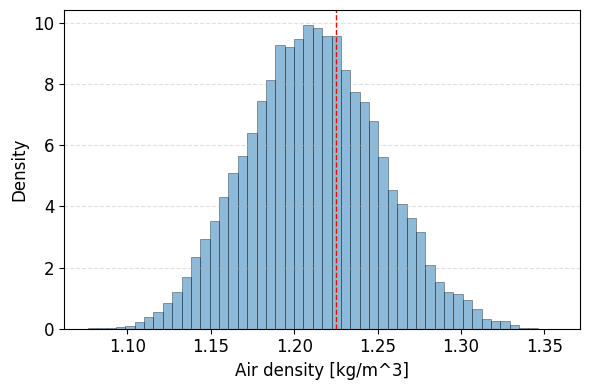

In [60]:
# plot mean density distribution

density = np.array(densities)

fig, ax = plt.subplots(figsize=(6, 4))


ax.hist(density, bins=50, density=True,
        alpha=0.5, color='C0', edgecolor='black', linewidth=0.5, label='ERA5 air density on hub heights')

ax.axvline(1.225, color='red', linestyle='--', linewidth=1)

ax.set_xlabel('Air density [kg/m^3]', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
#ax.set_title('Wind Speed Error Distribution', fontsize=12)
#ax.legend(fontsize=12, loc='lower left')
ax.tick_params(labelsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{save_path}/density_distr.png', dpi=600, bbox_inches='tight')
plt.show()

In [61]:
y_true_era5 = np.array(trues)
y_pred_era5 = np.array(preds)

In [62]:
files = os.listdir(reninja_dir)
station_files_reninja = [f for f in files if 'parameter' not in f and f.endswith('.csv')]
station_files_reninja.sort()
print(len(station_files_reninja), 'station files in synthetic data found')
turbine_params = pd.read_csv(os.path.join(reninja_dir, 'turbine_parameter.csv'), sep=';')
wind_params = pd.read_csv(os.path.join(reninja_dir, 'wind_parameter.csv'), sep=';', dtype={"park_id": str})
all_wind_params = pd.read_csv(os.path.join(locations_dir, 'wind_parameter.csv'), sep=';', dtype={"park_id": str})

timestamp_col = 'timestamp'
dfs = []
for st in station_files_reninja:
    station = pd.read_csv(os.path.join(reninja_dir, st), sep=';')
    station[timestamp_col] = pd.to_datetime(station[timestamp_col], utc=True)
    station.set_index(timestamp_col, inplace=True)
    #station = station['2024-01-01':'2024-12-31']
    #metadata = pd.read_csv(os.path.join(path, md))
    dfs.append(station)
    power_cols = [col for col in station.columns if 'power' in col]
    power = 0
    for col in power_cols:
        power += station[col]
    #power /= 1000 # convert to kW
    station['synthetic'] = power

id_of_interest = None#'04745'
results = defaultdict(list)
densities = []
trues, preds = [], []

for file, df in zip(station_files_reninja, dfs):
    print(f'Processing: {file}')
    if len(file) == 15:
        station_id = file.split('.')[0][-5:]
    else:
        station_id = file.split('.')[0][-7:]
    # initialize paths
    # get list of turbine ids t1,...
    turbines = turbine_params.loc[turbine_params.park_id == station_id]
    cut_in = turbines.cut_in.max()
    # get malo-id from station
    malo_ids = next_station.loc[next_station.park_id == station_id[:5]]['malo-id']
    malo_id = malo_ids.iloc[0]
    if malo_id in results['malo-id'] and station_id not in results['station_id']:
        malo_id = malo_ids.iloc[1]
    elif malo_id in results['malo-id'] and station_id in results['station_id']:
        continue
    results['malo-id'].append(str(malo_id))
    results['station_id'].append(station_id)
    df_compare = pd.concat([df[:meterdata[malo_id].index[-1]], meterdata[malo_id]], axis=1)
    # get mean wind_speed and density accross all heights
    # get park power curve
    power_curves = get_power_curves(turbine_path=turbine_path, turbine_params=turbines)
    power_curve = np.zeros(len(power_curves))
    for _, row in turbines.iterrows():
        power_curve += power_curves[row['turbine_name']]
    df_compare.rename(columns={malo_id: 'real'}, inplace=True)
    df_compare = df_compare.resample('1h', closed='left', label='left', origin='start').mean()
    # copy raw frame to filter outliers from real data
    df_lean = df_compare.copy()
    # remove 0 production where wind speed is > cut_in
    wind_speed_cols = [col for col in df_lean.columns if 'wind_speed_t' in col]
    df_lean['min_wind_speed'] = df_lean[wind_speed_cols].min(axis=1)
    # Outlier aus Cut-In Filter merken
    cut_in_outliers = df_lean[(df_lean['real'] == 0) & (df_lean['min_wind_speed'] >= cut_in)]
    df_lean = df_lean[~((df_lean['real'] == 0) & (df_lean['min_wind_speed'] >= cut_in))]
    # DBSCAN Outlier merken
    df_lean['wind_speed_hub'] = df_lean[[ws for ws in df_lean.columns if 'wind_speed' in ws]].mean(axis=1)
    X_db = df_lean[['wind_speed_hub', 'real']].dropna()
    X_scaled = StandardScaler().fit_transform(X_db)
    best_params = best_dbscan_params[station_id]
    labels = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples']).fit_predict(X_scaled)
    dbscan_outliers = df_lean.loc[X_db.index[labels == -1]]
    df_lean = df_lean.loc[X_db.index[labels != -1]]
    # Alle Outlier zusammenfassen
    outliers = pd.concat([cut_in_outliers, dbscan_outliers])
    bias = df_lean['real'] - df_lean['synthetic']
    df_lean['bias'] = bias
    sum_produced = df_lean[['synthetic', 'real']].sum(axis=0) / 1000 # divide by 2 when resolution is 30 min
    # get metrics
    y_true = df_lean.dropna()['real']
    y_pred = df_lean.dropna()['synthetic']
    r_2 = r2_score(y_true=y_true, y_pred=y_pred)
    installed_capacity = power_curve.max()
    y_true /= installed_capacity
    y_pred /= installed_capacity
    trues.extend(y_true)
    preds.extend(y_pred)
    mae = mean_absolute_error(y_true=y_true, y_pred=y_pred)
    results['r^2'].append(r_2)
    results['mae'].append(mae)
    results['sum_MWh_real'].append(sum_produced['real'])
    results['sum_MWh_synthetic'].append(sum_produced['synthetic'])
    results['installed_capacity'].append(installed_capacity)

results = next_station.merge(pd.DataFrame(results), on='malo-id', how='left')
#results.to_csv(os.path.join(results_dir, 'evaluation.csv'), index=False)

7 station files in synthetic data found
Processing: 00198_1.csv
Processing: 00198_2.csv
Processing: 00282.csv
Processing: 02483.csv
Processing: 04745.csv
Processing: 05347.csv
Processing: 05426.csv


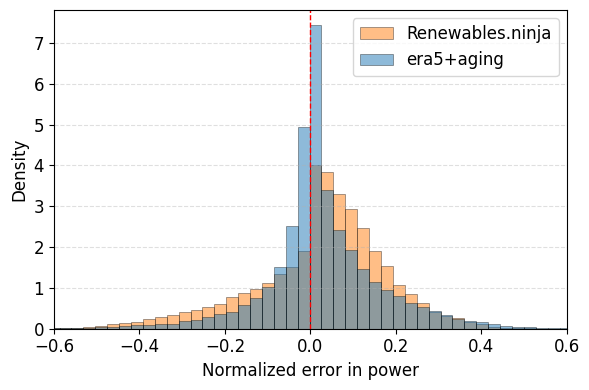

In [63]:
y_true_reninja = np.array(trues)
y_pred_reninja = np.array(preds)

error_era5 = y_pred_era5 - y_true_era5
error_reninja = y_pred_reninja - y_true_reninja

fig, ax = plt.subplots(figsize=(6, 4))

bins = np.linspace(min(error_era5.min(), error_reninja.min()),
                   max(error_era5.max(), error_reninja.max()), 60)

ax.hist(error_reninja, bins=bins, density=True,
        alpha=0.5, color='C1', edgecolor='black', linewidth=0.5, label='Renewables.ninja')
ax.hist(error_era5, bins=bins, density=True,
        alpha=0.5, color='C0', edgecolor='black', linewidth=0.5, label='era5+aging')

ax.axvline(0, color='red', linestyle='--', linewidth=1)

ax.set_xlabel('Normalized error in power', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-0.6, 0.6)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{save_path}/error_distr_power.png', dpi=600, bbox_inches='tight')
plt.show()